In [48]:
import requests, time, random, json, warnings
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import scipy.stats as stats
from scipy.interpolate import make_interp_spline
from datetime import datetime
warnings.filterwarnings('ignore')

In [93]:
# Codeforces canonical rank colours (matches CF website)
CF_COLOURS = {
    'Newbie':             '#808080',
    'Pupil':              '#008000',
    'Specialist':         '#03A89E',
    'Expert':             '#0000FF',
    'Candidate Master':   '#AA00AA',
    'Master':             '#FF8C00',
    'International Master': '#FF8C00',
    'Grandmaster':        '#FF0000',
    'International Grandmaster': '#FF0000',
    'Legendary Grandmaster': '#FF0000',
    'Tourist':            '#000000',  # placeholder
}

CF_RATING_BANDS = [
    (0,    1199,  'Newbie',              '#808080'),
    (1200, 1399,  'Pupil',               '#008000'),
    (1400, 1599,  'Specialist',          '#03A89E'),
    (1600, 1899,  'Expert',              '#0000FF'),
    (1900, 2099,  'Candidate Master',    '#AA00AA'),
    (2100, 2299,  'Master',              '#FF8C00'),
    (2300, 2399,  'International Master','#FF8C00'),
    (2400, 2599,  'Grandmaster',         '#FF0000'),
    (2600, 2999,  'Intl. Grandmaster',   '#FF0000'),
    (3000, 9999,  'Legendary GM',        '#FF0000'),
]

def rating_to_rank(r):
    for lo, hi, rank, col in CF_RATING_BANDS:
        if lo <= r <= hi:
            return rank, col
    return 'Unrated', '#808080'

Client (your code) → HTTP Request → Codeforces Server → JSON Response → Processing → Data Structure

Each row in your dataframe = one instance of User class

+------------------------+
| CodeforcesAPIClient    |
|------------------------|
| + get_rated_users()    |
+-----------+------------+
            |
            v
+------------------------+
| ApiResponse            |
|------------------------|
| status                 |
| result (List<User>)    |
+-----------+------------+
            |
            v
+------------------------+
| User                   |
|------------------------|
| handle                 |
| rating                 |
| rank                   |
| country                |
+------------------------+
            |
            v
+------------------------+
| DataFrame (Collection) |
+------------------------+

In [ ]:
BASE_URL = "https://codeforces.com/api"

def fetch_cf_users(active_only=True):
    url = f"{BASE_URL}/user.ratedList?activeOnly={str(active_only).lower()}"
    
    print("Fetching Codeforces users...")
    response = requests.get(url)
    
    if response.status_code != 200:
        raise Exception("Failed to fetch data")
    
    data = response.json()
    
    if data['status'] != 'OK':
        raise Exception(data.get('comment', 'Unknown API error'))
    
    users = data['result']
    print(f"Total users fetched: {len(users)}")
    
    return data

In [6]:
data = fetch_cf_users(active_only=True)

Fetching Codeforces users...
Total users fetched: 38818


In [9]:
data[0:5]

[{'lastName': 'Korotkevich',
  'country': 'Belarus',
  'lastOnlineTimeSeconds': 1774885752,
  'city': 'Gomel',
  'rating': 3755,
  'friendOfCount': 87954,
  'titlePhoto': 'https://userpic.codeforces.org/422/title/50a270ed4a722867.jpg',
  'handle': 'tourist',
  'avatar': 'https://userpic.codeforces.org/422/avatar/2b5dbe87f0d859a2.jpg',
  'firstName': 'Gennady',
  'contribution': 0,
  'organization': 'ITMO University',
  'rank': 'legendary grandmaster',
  'maxRating': 4009,
  'registrationTimeSeconds': 1265987288,
  'maxRank': 'tourist'},
 {'lastName': 'He',
  'country': 'United States',
  'lastOnlineTimeSeconds': 1774809265,
  'city': 'Cupertino',
  'rating': 3696,
  'friendOfCount': 11685,
  'titlePhoto': 'https://userpic.codeforces.org/no-title.jpg',
  'handle': 'ecnerwala',
  'avatar': 'https://userpic.codeforces.org/no-avatar.jpg',
  'firstName': 'Andrew',
  'contribution': 0,
  'organization': 'MIT',
  'rank': 'legendary grandmaster',
  'maxRating': 3844,
  'registrationTimeSeconds

In [ ]:
#Finding count of indian users , country = India

indian_users = [user for user in data if user.get('country', '').lower() == 'india']
print(f"Total Indian users: {len(indian_users)}")

Total Indian users: 7531


In [11]:
#Finding count of users in organization = IIT Bhilai

iit_bhilai_users = [user for user in data if user.get('organization', '').lower() == 'iit bhilai']
print(f"Total IIT Bhilai users: {len(iit_bhilai_users)}")

Total IIT Bhilai users: 32


In [16]:
#Listing handle of iit bhilai users

for user in iit_bhilai_users :
    print(user['handle'])

nebul7
arpit_kr
kingAB
Herodotus_07
LordKRiS
vidit_shrimali
namankansara0611
BuzzKillRaven
zwix
_gouravgour_
sravan_1234
srivarshith
Suyash_06
piy6291
zenji
harsh4890
kinshuk18
KushalRadia
pranay_sb
adarshsm
adi_interstellar
palak1904
Ratish001
intergalacticelephant
Prince_Hadke
Kanadb
sumagnadas
Adhiagrawal
Johncena1312
Soumyajit_Das
Prashant-SG
Krish_3001


In [46]:
# Trying method 2 for fetching users

CF_BASE = "https://codeforces.com/api" 

def cf_get(endpoint, params=None, retries=4, wait=2.5):
    """Polite GET with retry logic. Respects CF rate limit (~1 req/sec)."""
    url = f'{CF_BASE}/{endpoint}'
    for attempt in range(retries):
        try:
            resp = requests.get(url, params=params, timeout=20)
            data = resp.json()
            if data.get('status') == 'OK':
                return data['result']
            else:
                comment = data.get('comment', 'Unknown error')
                print(f'  ⚠ CF API error ({attempt+1}/{retries}): {comment}')
                time.sleep(wait * (attempt + 1))
        except Exception as e:
            print(f'  ⚠ Request error ({attempt+1}/{retries}): {e}')
            time.sleep(wait * (attempt + 1))
    return None

def get_country_users(country='India', max_users = 97000):
    """Fetch rated users from a country via user.ratedList."""
    print(f'📥 Fetching rated users for country={country} ...')
    result = cf_get('user.ratedList', params={'activeOnly': 'false', 'includeRetired': 'true'})
    if result is None:
        print('  ❌ Failed to fetch user list. Using synthetic demo data.')
        return None
    india = [u for u in result if u.get('country', '') == country]
    print(f'  ✅ Found {len(india)} Indian handles on Codeforces.')
    return india[:min(len(india), max_users)]

In [4]:
data2 = get_country_users()

📥 Fetching rated users for country=India ...
  ✅ Found 97477 Indian handles on Codeforces.


In [5]:
len(data2)

97000

In [6]:
type(data2)

list

In [8]:
#Save data2 to json file

with open('indian_users.json', 'w') as f:
    json.dump(data2, f, indent=2)

In [7]:
data2[0:5]

[{'lastName': 'Ray',
  'country': 'India',
  'lastOnlineTimeSeconds': 1775342328,
  'city': 'Kolkata',
  'rating': 3083,
  'friendOfCount': 18421,
  'titlePhoto': 'https://userpic.codeforces.org/2716850/title/7d13621c709ac866.jpg',
  'handle': 'Dominater069',
  'avatar': 'https://userpic.codeforces.org/2716850/avatar/6f087eab6958a0a8.jpg',
  'firstName': 'Shreyan',
  'contribution': 0,
  'organization': 'IIT Kharagpur',
  'rank': 'legendary grandmaster',
  'maxRating': 3167,
  'registrationTimeSeconds': 1660061734,
  'maxRank': 'legendary grandmaster'},
 {'lastName': 'Gupta',
  'country': 'India',
  'lastOnlineTimeSeconds': 1726270632,
  'city': 'New Delhi',
  'rating': 2753,
  'friendOfCount': 6518,
  'titlePhoto': 'https://userpic.codeforces.org/no-title.jpg',
  'handle': 'kal013',
  'avatar': 'https://userpic.codeforces.org/no-avatar.jpg',
  'firstName': 'Kalash',
  'contribution': 0,
  'organization': 'IIT Delhi',
  'rank': 'international grandmaster',
  'maxRating': 2891,
  'regis

In [2]:
import pandas as pd

In [6]:
#Converting into pandas dataframe

df = pd.read_json('indian_users.json')

In [7]:
df.shape

(97000, 19)

In [8]:
# Time features
df['registration_date'] = pd.to_datetime(df['registrationTimeSeconds'], unit='s')
df['last_online'] = pd.to_datetime(df['lastOnlineTimeSeconds'], unit='s')

df['year'] = df['registration_date'].dt.year

# Account age
df['account_age_days'] = (pd.Timestamp.now() - df['registration_date']).dt.days

# Activity proxy (important)
df['days_since_last_online'] = (pd.Timestamp.now() - df['last_online']).dt.days

In [9]:
summary = {
    "total_users": len(df),
    "avg_rating": df['rating'].mean(),
    "median_rating": df['rating'].median(),
    "max_rating": df['rating'].max(),
    "avg_max_rating": df['maxRating'].mean(),
}

print(summary)

{'total_users': 97000, 'avg_rating': np.float64(1166.5227525773196), 'median_rating': 1179.0, 'max_rating': 3083, 'avg_max_rating': np.float64(1254.0088350515464)}


In [10]:
df['rating'].quantile([0.25, 0.5, 0.75, 0.9, 0.99])

0.25     927.0
0.50    1179.0
0.75    1414.0
0.90    1621.0
0.99    1986.0
Name: rating, dtype: float64

In [11]:
rank_dist = df['rank'].value_counts()
print(rank_dist)

rank
newbie                       50444
pupil                        20439
specialist                   14659
expert                        9432
candidate master              1444
master                         513
international master            32
grandmaster                     31
international grandmaster        5
legendary grandmaster            1
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

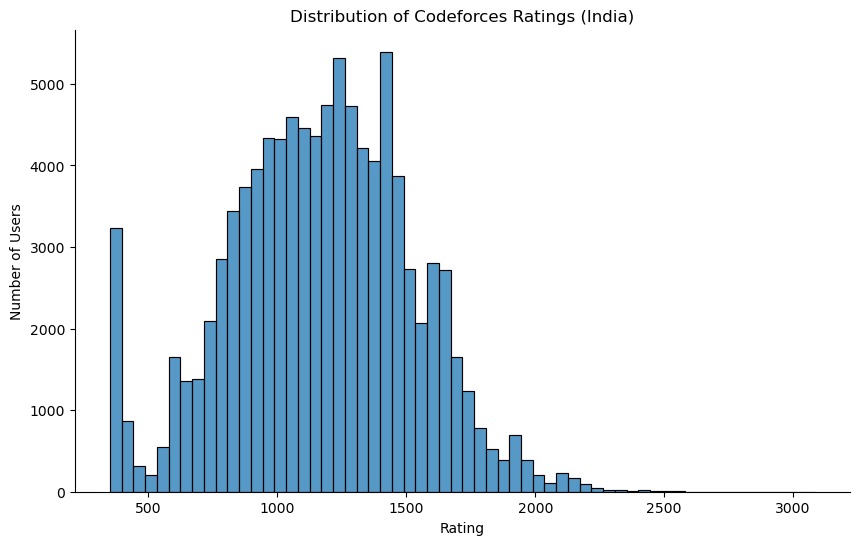

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(df['rating'], bins=60)

plt.title("Distribution of Codeforces Ratings (India)")
plt.xlabel("Rating")
plt.ylabel("Number of Users")

sns.despine()
plt.show()

In [13]:
# Create bins (like CF)
bins = list(range(0, 3600, 50))
df['rating_bin'] = pd.cut(df['rating'], bins=bins)

In [14]:
dist = df.groupby('rating_bin').size().reset_index(name='count')

/tmp/ipykernel_178122/3993857776.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist = df.groupby('rating_bin').size().reset_index(name='count')


In [15]:
dist['cum_count'] = dist['count'].cumsum()

total_users = dist['count'].sum()

dist['percentile'] = dist['cum_count'] / total_users * 100

In [14]:
import plotly.express as px

# Convert bins to string for plotting
dist['rating_range'] = dist['rating_bin'].astype(str)

fig = px.bar(
    dist,
    x='rating_range',
    y='count',
    title="Codeforces Rating Distribution (India)",
)

# Add custom hover (THIS IS KEY 🔥)
fig.update_traces(
    customdata=dist[['percentile']],
    hovertemplate=
    "<b>%{x}</b><br>" +
    "Users: %{y}<br>" +
    "Percentile: %{customdata[0]:.2f}%<extra></extra>"
)

fig.update_layout(
    xaxis_title="Rating Range",
    yaxis_title="Number of Users",
    xaxis_tickangle=-45
)

fig.show()

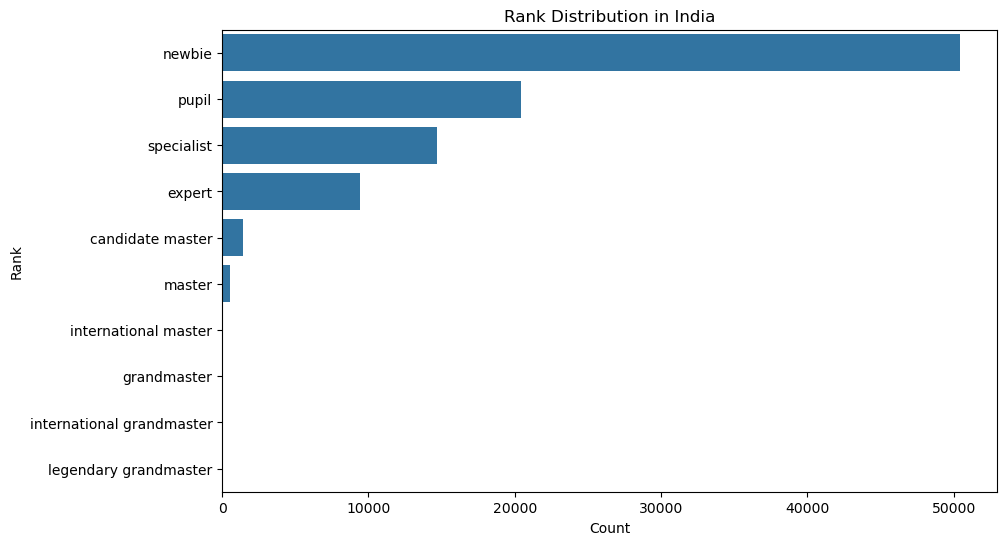

In [15]:
plt.figure(figsize=(10,6))

rank_order = [
    'newbie','pupil','specialist','expert',
    'candidate master','master','international master',
    'grandmaster','international grandmaster','legendary grandmaster'
]

sns.countplot(data=df, y='rank', order=rank_order)

plt.title("Rank Distribution in India")
plt.xlabel("Count")
plt.ylabel("Rank")

plt.show()

In [16]:
#Plotting a pie chart showing distribution of ranks in india using plotly express

rank_counts = df['rank'].value_counts().reset_index()
rank_counts.columns = ['rank', 'count']
fig = px.pie(
    rank_counts,
    names='rank',
    values='count',
    title="Rank Distribution in India",
    color='rank',
    color_discrete_map=CF_COLOURS
)
fig.show()

In [16]:
df.columns

Index(['lastName', 'country', 'lastOnlineTimeSeconds', 'city', 'rating',
       'friendOfCount', 'titlePhoto', 'handle', 'avatar', 'firstName',
       'contribution', 'organization', 'rank', 'maxRating',
       'registrationTimeSeconds', 'maxRank', 'email', 'openId', 'vkId',
       'registration_date', 'last_online', 'year', 'account_age_days',
       'days_since_last_online', 'rating_bin'],
      dtype='object')

In [17]:
df['year'].min(), df['year'].max()

(1970, 2026)

In [18]:
#Count of years less than 2010

df[df['year'] < 2010].shape[0]

1

In [19]:
#Remove outliers with registration year < 2010
df = df[df['year'] >= 2010]

In [20]:
yearly = df.groupby('year').size().reset_index(name='new_users')
yearly = yearly.sort_values('year')

yearly['cumulative'] = yearly['new_users'].cumsum()

In [22]:
#Plotting interactive plotly line chart for growth of indian codeforces users

fig = px.line(
    yearly,
    x='year',
    y='cumulative',
    title="Growth of Indian Codeforces Users",
    markers=True
)

fig.update_traces(line=dict(width=3))
fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Total Users",
    hovermode="x unified"
)

fig.show()

In [23]:
top_cities = df['city'].value_counts().head(15)

#Plotting top cities in india using plotly express

fig = px.bar(
    x=top_cities.values,
    y=top_cities.index, 
    title="Top Coding Cities in India"
)
fig.update_layout(
    xaxis_title="Number of Users",
    yaxis_title="Cities"
)
fig.show()

#Most codeforces account are from Hyderabad.

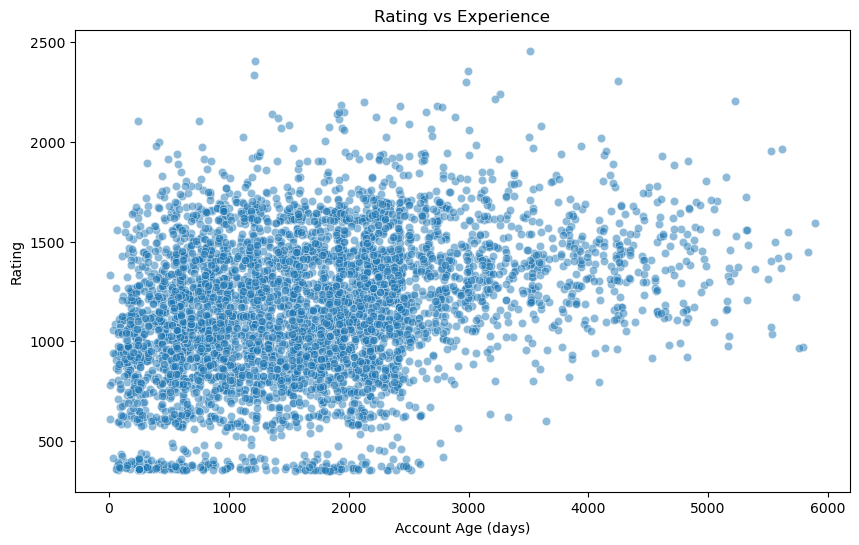

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(5000),
    x='account_age_days',
    y='rating',
    alpha=0.5
)

plt.title("Rating vs Experience")
plt.xlabel("Account Age (days)")
plt.ylabel("Rating")

plt.show()

In [21]:
df.columns

Index(['lastName', 'country', 'lastOnlineTimeSeconds', 'city', 'rating',
       'friendOfCount', 'titlePhoto', 'handle', 'avatar', 'firstName',
       'contribution', 'organization', 'rank', 'maxRating',
       'registrationTimeSeconds', 'maxRank', 'email', 'openId', 'vkId',
       'registration_date', 'last_online', 'year', 'account_age_days',
       'days_since_last_online', 'rating_bin'],
      dtype='object')

In [22]:
def get_user_rating(handle):
    """
    Fetch contest history for a user.
    Returns:
        List of rating change objects OR None
    """
    result = cf_get('user.rating', params={'handle': handle})
    
    if result is None:
        return None
    
    # Clean structure
    return [
        {
            'handle': handle,
            'contestId': r['contestId'],
            'contestName': r['contestName'],
            'rank': r['rank'],
            'oldRating': r['oldRating'],
            'newRating': r['newRating'],
            'ratingChange': r['newRating'] - r['oldRating'],
            'timestamp': r['ratingUpdateTimeSeconds']
        }
        for r in result
    ]

In [23]:
def get_user_submissions(handle, max_subs=10000):
    """
    Fetch submissions for a user.
    Returns:
        List of cleaned submission objects
    """
    result = cf_get('user.status', params={'handle': handle})
    
    if result is None:
        return None
    
    submissions = []
    
    for s in result[:max_subs]:
        problem = s.get('problem', {})
        author = s.get('author', {})
        
        submissions.append({
            'handle': handle,
            'contestId': problem.get('contestId'),
            'problem_index': problem.get('index'),
            'rating': problem.get('rating'),
            'tags': problem.get('tags', []),
            'verdict': s.get('verdict'),
            'participantType': author.get('participantType'),
            'creationTime': s.get('creationTimeSeconds')
        })
    
    return submissions

In [42]:
def fetch_user_data(handles, sleep_time=2.2, max_users=100):
    """
    Fetch both rating + submission data for a sample of users.
    """
    all_ratings = []
    all_submissions = []
    
    for i, h in enumerate(handles[:max_users]):
        print(f"📦 Processing {i+1}/{max_users}: {h}")
        
        # Fetch rating
        rating_data = get_user_rating(h)
        if rating_data:
            all_ratings.extend(rating_data)
        
        time.sleep(sleep_time)
        
        # Fetch submissions
        subs_data = get_user_submissions(h)
        if subs_data:
            all_submissions.extend(subs_data)
        
        time.sleep(sleep_time)
    
    return all_ratings, all_submissions

In [43]:
def stratified_sample(df, n_per_group=100):
    """
    Sample users across rating bands
    """
    samples = []
    
    for rank in df['rank'].unique():
        group = df[df['rank'] == rank]
        sampled = group.sample(min(len(group), n_per_group))
        samples.append(sampled)
    
    return pd.concat(samples)

In [44]:
sample_df = stratified_sample(df, n_per_group=50)
handles = sample_df['handle'].tolist()

In [49]:
df_rating, df_subs = fetch_user_data(handles, max_users=1000)

📦 Processing 1/1000: Dominater069
📦 Processing 2/1000: MridulAhi
  ⚠ Request error (1/4): ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
📦 Processing 3/1000: T1duS
📦 Processing 4/1000: yashChandnani
📦 Processing 5/1000: kal013
📦 Processing 6/1000: kshitij_sodani
📦 Processing 7/1000: pranjal.ssh
📦 Processing 8/1000: doped.silicon
📦 Processing 9/1000: amit_swami
📦 Processing 10/1000: rivalq
📦 Processing 11/1000: TinTin_in_Quant
📦 Processing 12/1000: AwakeAnay
📦 Processing 13/1000: CoderAnshu
📦 Processing 14/1000: arnabmanna
📦 Processing 15/1000: Ashishgup
📦 Processing 16/1000: BhaskarTM
📦 Processing 17/1000: jtnydv25
📦 Processing 18/1000: -...-
📦 Processing 19/1000: rajat1603
📦 Processing 20/1000: harsh__h
📦 Processing 21/1000: amnesiac_dusk
📦 Processing 22/1000: pikel_rik
📦 Processing 23/1000: yash_daga
📦 Processing 24/1000: ElDiablo
📦 Processing 25/1000: Everule
📦 Processing 26/1000: i_will_be_less_than_blue
📦 Processing 27/1000: Baba
📦 Processing 28/100

In [24]:
df_rating = pd.read_json('sample_user_ratings.json')
df_subs = pd.read_json('sample_user_submissions.json')

In [27]:
len(df_rating)

18948

In [28]:
len(df_subs)

516742

In [ ]:
df_rating[87]

{'handle': 'Dominater069',
 'contestId': 2196,
 'contestName': 'Codeforces Round 1079 (Div. 1)',
 'rank': 36,
 'oldRating': 3125,
 'newRating': 3083,
 'ratingChange': -42,
 'timestamp': 1770831300}

In [ ]:
#Save rating and submission data to json files

# with open('sample_user_ratings.json', 'w') as f:
#     json.dump(df_rating, f, indent=2)

# with open('sample_user_submissions.json', 'w') as f:
#     json.dump(df_subs, f, indent=2)

In [30]:
#Plotting rating line chart of Dominater069

dom_ratings = []
dom_timestamps = []
for it in df_rating:
    if it['handle'] == 'Dominater069':
        dom_ratings.append(it['newRating'])
        dom_timestamps.append(it['timestamp'])

TypeError: string indices must be integers, not 'str'

In [74]:
#Plot using ploty express such that hover will give you exact date and rating of that point in line chart

dom_dates = [datetime.fromtimestamp(ts) for ts in dom_timestamps]
fig = px.line(
    x=dom_dates,
    y=dom_ratings,
    title="Rating History of Dominater069",
    markers=True
)

fig.update_traces(line=dict(width=3))

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Rating",
    hovermode="x unified"
)

fig.show()

In [31]:
type(df_rating)

pandas.core.frame.DataFrame

In [25]:
df_rating.columns , df_rating.shape

(Index(['handle', 'contestId', 'contestName', 'rank', 'oldRating', 'newRating',
        'ratingChange', 'timestamp'],
       dtype='object'),
 (18948, 8))

In [26]:
df_subs.columns , df_subs.shape

(Index(['handle', 'contestId', 'problem_index', 'rating', 'tags', 'verdict',
        'participantType', 'creationTime'],
       dtype='object'),
 (516742, 8))

Behavioural Analysis

In [27]:
contest_count = df_rating.groupby('handle').size()

In [28]:
growth_velocity = (
    df_rating.groupby('handle')
    .apply(lambda x: (x['newRating'].iloc[-1] - x['oldRating'].iloc[0]) / len(x))
)

/tmp/ipykernel_178122/2699315032.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['newRating'].iloc[-1] - x['oldRating'].iloc[0]) / len(x))


In [29]:
df_rating.columns

Index(['handle', 'contestId', 'contestName', 'rank', 'oldRating', 'newRating',
       'ratingChange', 'timestamp'],
      dtype='object')

In [30]:
def time_to_reach(df, threshold):
    df = df.sort_values('timestamp')
    
    reached = df[df['newRating'] >= threshold]
    
    if len(reached) == 0:
        return None
    
    start_time = df.iloc[0]['timestamp']
    reach_time = reached.iloc[0]['timestamp']
    
    return (reach_time - start_time).days

In [31]:
time_to_1400 = df_rating.groupby('handle').apply(lambda x: time_to_reach(x, 1400))
time_to_1600 = df_rating.groupby('handle').apply(lambda x: time_to_reach(x, 1600))

/tmp/ipykernel_178122/1070256012.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_to_1400 = df_rating.groupby('handle').apply(lambda x: time_to_reach(x, 1400))
/tmp/ipykernel_178122/1070256012.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_to_1600 = df_rating.groupby('handle').apply(lambda x: time_to_reach(x, 1600))


In [32]:
time_to_1400.shape

(369,)

In [33]:
# Summary Statistics for time to reach 1400 and 1600

time_to_1400.describe()

count     291.000000
mean      120.718213
std       208.616534
min         0.000000
25%         0.000000
50%        23.000000
75%       181.500000
max      1845.000000
dtype: float64

In [34]:
time_to_1600.describe()

count     236.000000
mean      223.084746
std       241.091422
min         0.000000
25%        44.000000
50%       153.000000
75%       330.750000
max      1859.000000
dtype: float64

In [35]:
df_subs.columns

Index(['handle', 'contestId', 'problem_index', 'rating', 'tags', 'verdict',
       'participantType', 'creationTime'],
      dtype='object')

In [36]:
# See different variables in participantType column of df_subs

df_subs['participantType'].value_counts()

participantType
PRACTICE              277476
CONTESTANT            137149
VIRTUAL                74885
OUT_OF_COMPETITION     27232
Name: count, dtype: int64

In [37]:
upsolve_ratio = (
    df_subs[df_subs['verdict']=='OK']
    .groupby('handle')['participantType']
    .apply(lambda x: (x=='PRACTICE').mean())
)

In [38]:
in_contest_solve_ratio = (
    df_subs[df_subs['verdict']=='OK']
    .groupby('handle')['participantType']
    .apply(lambda x: (x=='CONTESTANT').mean())
)

In [39]:
total_problems_solved = (
    df_subs[df_subs['verdict']=='OK']
    .groupby('handle')
    .size()
)

In [40]:
accuracy = (
    df_subs.groupby('handle')
    .apply(lambda x: (x['verdict']=='OK').mean())
)

/tmp/ipykernel_178122/2666811698.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['verdict']=='OK').mean())


In [59]:
df_subs.columns

Index(['handle', 'contestId', 'problem_index', 'rating', 'tags', 'verdict',
       'participantType', 'creationTime'],
      dtype='object')

In [61]:
#Inspect creationTime

df_subs['creationTime'][0]

np.int64(1775061087)

In [43]:
df_subs['creationTime'] = pd.to_datetime(df_subs['creationTime'], unit='s')

In [44]:
df_subs['creationTime'][0]

Timestamp('2026-04-01 16:31:27')

In [41]:
avg_difficulty = (
    df_subs[df_subs['verdict']=='OK']
    .groupby('handle')['rating']
    .mean()
)

In [45]:
active_days = (
    df_subs.groupby('handle')['creationTime']
    .apply(lambda x: x.dt.date.nunique())
)

In [47]:
submission_freq = (
    df_subs.groupby('handle')
    .apply(lambda x: len(x) / ((x['creationTime'].max() - x['creationTime'].min()).days + 1))
)

/tmp/ipykernel_178122/1424180378.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: len(x) / ((x['creationTime'].max() - x['creationTime'].min()).days + 1))


In [109]:
features = pd.DataFrame({
    'contest_count': contest_count,
    'growth_velocity': growth_velocity,
    'total_problems_solved': total_problems_solved,
    'time_to_1400': time_to_1400,
    'time_to_1600': time_to_1600,
    'upsolve_ratio': upsolve_ratio,
    'in_contest_solve_ratio': in_contest_solve_ratio,
    'avg_difficulty': avg_difficulty,
    'submission_freq': submission_freq,
    'active_days': active_days,
    'accuracy': accuracy
}).reset_index()

In [ ]:
#Save it as features.csv

# features.to_csv('user_features.csv', index=False)

In [52]:
def categorize_cp_topics(tags):
    """
    Categorizes CP tags into First Principle buckets.
    Buckets: DP, Greedy, Maths, Strings, Graphs, and the necessary 6th: Search/Infrastructure.
    """
    
    # Mapping based on underlying structure
    taxonomy = {
        "DP": [
            "dp", "bitmasks", "divide and conquer"
        ],
        "Greedy": [
            "greedy", "constructive algorithms", "schedules", "sortings"
        ],
        "Maths": [
            "math", "number theory", "combinatorics", "geometry", 
            "probabilities", "matrices", "fft", "games", 
            "chinese remainder theorem", "ternary search"
        ],
        "Strings": [
            "strings", "string suffix structures", "hashing", "expression parsing"
        ],
        "Graphs": [
            "graphs", "trees", "dfs and similar", "shortest paths", 
            "flows", "graph matchings", "2-sat", "dsu"
        ],
        "Implementation": [
            "binary search", "data structures", "two pointers", 
            "brute force", "meet-in-the-middle", "implementation", 
            "interactive", "communication"
        ]
    }

    # Invert mapping for O(1) lookup
    tag_to_category = {tag: cat for cat, tags_list in taxonomy.items() for tag in tags_list}
    
    categorized = {cat: [] for cat in taxonomy.keys()}
    uncategorized = []

    for tag in tags:
        category = tag_to_category.get(tag.lower())
        if category:
            categorized[category].append(tag)
        else:
            uncategorized.append(tag)

    return categorized, uncategorized

# Input data extracted from your list
raw_tags = [
    "2-sat", "binary search", "bitmasks", "brute force", "chinese remainder theorem",
    "combinatorics", "communication", "constructive algorithms", "data structures",
    "dfs and similar", "divide and conquer", "dp", "dsu", "expression parsing",
    "fft", "flows", "games", "geometry", "graph matchings", "graphs", "greedy",
    "hashing", "implementation", "interactive", "math", "matrices", 
    "meet-in-the-middle", "number theory", "probabilities", "schedules",
    "shortest paths", "sortings", "string suffix structures", "strings",
    "ternary search", "trees", "two pointers"
]

mp, missing = categorize_cp_topics(raw_tags)

# Print Summary
print(f"{'Category':<25} | {'Topics'}")
print("-" * 60)
for category, topics in mp.items():
    print(f"{category:<25} | {', '.join(topics)}")

if missing:
    print(f"\nUncategorized: {', '.join(missing)}")

Category                  | Topics
------------------------------------------------------------
DP                        | bitmasks, divide and conquer, dp
Greedy                    | constructive algorithms, greedy, schedules, sortings
Maths                     | chinese remainder theorem, combinatorics, fft, games, geometry, math, matrices, number theory, probabilities, ternary search
Strings                   | expression parsing, hashing, string suffix structures, strings
Graphs                    | 2-sat, dfs and similar, dsu, flows, graph matchings, graphs, shortest paths, trees
Implementation            | binary search, brute force, communication, data structures, implementation, interactive, meet-in-the-middle, two pointers


In [58]:
df_tags = df_subs[df_subs['verdict'] == 'OK'].copy()

# explode tags
df_tags = df_tags.explode('tags')
df_tags['tags'] = df_tags['tags'].str.lower()

In [59]:
def map_tag(tag):
    for cat, tags_list in mp.items():
        if tag in tags_list:
            return cat
    return None

df_tags['category'] = df_tags['tags'].apply(map_tag)
df_tags = df_tags[df_tags['category'].notna()]

In [60]:
df_tags['category'].value_counts()

category
Implementation    197980
Greedy            169802
Maths             136499
Graphs             68953
DP                 63211
Strings            24891
Name: count, dtype: int64

In [61]:
df_tags = df_tags.merge(
    df[['handle', 'rating']],
    on='handle',
    how='left'
)

In [62]:
bins = [0,1200,1400,1600,1900,2100,2400,4000]
labels = ['Newbie','Pupil','Specialist','Expert','CM','Master','GM']

df_tags['rating_bucket'] = pd.cut(df['rating'], bins=bins, labels=labels)

In [65]:
df_tags.columns

Index(['handle', 'contestId', 'problem_index', 'rating_x', 'tags', 'verdict',
       'participantType', 'creationTime', 'category', 'rating_y',
       'rating_bucket'],
      dtype='object')

In [66]:
mastery = (
    df_tags.groupby(['rating_bucket','category'])['rating_x']
    .mean()
    .reset_index()
)

/tmp/ipykernel_178122/3074532190.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tags.groupby(['rating_bucket','category'])['rating_x']


In [68]:
radar_df = mastery.pivot(index='rating_bucket', columns='category', values='rating_x')
radar_df = radar_df.fillna(0)

In [70]:
import plotly.graph_objects as go

categories = list(radar_df.columns)
categories_loop = categories + [categories[0]]

# 🔥 Choose base level
base_level = 'Expert'
base_values = radar_df.loc[base_level].values.tolist()
base_values += base_values[:1]

fig = go.Figure()

# 🔹 Base trace (always visible)
fig.add_trace(go.Scatterpolar(
    r=base_values,
    theta=categories_loop,
    fill='toself',
    name=f"Base: {base_level}",
    line=dict(color='blue', width=3),
    opacity=0.6
))

# 🔹 Add all other traces (initially hidden)
traces = []
buttons = []

for i, level in enumerate(radar_df.index):
    values = radar_df.loc[level].values.tolist()
    values += values[:1]
    
    visible = [True] + [False]*len(radar_df.index)  # base always visible
    
    # mark this trace visible when selected
    visible[i+1] = True
    
    trace = go.Scatterpolar(
        r=values,
        theta=categories_loop,
        fill='toself',
        name=str(level),
        visible=False,
        opacity=0.5
    )
    
    fig.add_trace(trace)
    
    buttons.append(dict(
        label=str(level),
        method="update",
        args=[{"visible": visible},
              {"title": f"Comparison: {base_level} vs {level}"}]
    ))

# 🔥 Add dropdown
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.1,
            y=1.1
        )
    ]
)

# 🔥 Styling
fig.update_layout(
    title=f"Topic Mastery Comparison (Base: {base_level})",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[800, 2600]
        )
    ),
    showlegend=True
)

fig.show()

In [110]:
features.shape

(369, 12)

In [73]:
features.columns

Index(['handle', 'contest_count', 'growth_velocity', 'time_to_1400',
       'time_to_1600', 'upsolve_ratio', 'in_contest_solve_ratio',
       'avg_difficulty', 'submission_freq', 'active_days', 'accuracy'],
      dtype='object')

In [72]:
features.describe()

,contest_count,growth_velocity,time_to_1400,time_to_1600,upsolve_ratio,in_contest_solve_ratio,avg_difficulty,submission_freq,active_days,accuracy
count,369.000000,369.000000,291.000000,236.000000,369.000000,369.000000,369.000000,369.000000,369.000000,369.000000
mean,51.349593,95.191272,120.718213,223.084746,0.486253,0.392938,1284.019030,1.152473,202.113821,0.482681
std,45.401467,152.292896,208.616534,241.091422,0.254177,0.254375,281.166082,1.144096,194.038580,0.110780
min,1.000000,8.192469,0.000000,0.000000,0.000000,0.000000,800.000000,0.006672,1.000000,0.100000
25%,15.000000,25.917647,0.000000,44.000000,0.281583,0.202381,1036.363636,0.325203,43.000000,0.413010
50%,38.000000,44.214286,23.000000,153.000000,0.504084,0.316327,1280.125786,0.846311,140.000000,0.483826
75%,77.000000,91.294118,181.500000,330.750000,0.684685,0.511628,1503.019538,1.647931,303.000000,0.545455
max,239.000000,1407.000000,1845.000000,1859.000000,1.000000,1.000000,2084.356895,11.246154,966.000000,1.000000


In [74]:
features.isna().sum()

handle                      0
contest_count               0
growth_velocity             0
time_to_1400               78
time_to_1600              133
upsolve_ratio               0
in_contest_solve_ratio      0
avg_difficulty              0
submission_freq             0
active_days                 0
accuracy                    0
dtype: int64

In [78]:
#Maximum user rating for a handle in our sample using groupby and max

min(df_rating.groupby('handle')['newRating'].max())

385

In [81]:
import plotly.express as px

In [86]:
#Plotting users v/s their max newRating using plotly express histogram bins

fig = px.histogram(
    df_rating.groupby('handle')['newRating'].max().reset_index(name='max_rating'),
    x='max_rating',
    nbins=30,
    title="Distribution of Max Ratings in Sample"
)

fig.update_layout(
    xaxis_title="Max Rating",
    yaxis_title="Number of Users"
)

fig.show()


In [84]:
df_rating.columns

Index(['handle', 'contestId', 'contestName', 'rank', 'oldRating', 'newRating',
       'ratingChange', 'timestamp'],
      dtype='object')

In [111]:
df_final = df.merge(
    features,
    on='handle',
    how='inner'
)

In [120]:
#Saving the df_final as ultimate dataset for analysis

df_final.to_csv('final_user_data.csv', index=False)

In [102]:
CF_COLOURS = {
    'Newbie':             '#808080',
    'Pupil':              '#008000',
    'Specialist':         '#03A89E',
    'Expert':             '#0000FF',
    'Candidate Master':   '#AA00AA',
    'Master':             '#FF8C00',
    'International Master': '#FF8C00',
    'Grandmaster':        '#FF0000',
    'International Grandmaster': '#FF0000',
    'Legendary Grandmaster': '#FF0000',
    'Tourist':            '#000000',  # placeholder
}

CF_RATING_BANDS = [
    (0,    1199,  'Newbie',              '#808080'),
    (1200, 1399,  'Pupil',               '#008000'),
    (1400, 1599,  'Specialist',          '#03A89E'),
    (1600, 1899,  'Expert',              '#0000FF'),
    (1900, 2099,  'Candidate Master',    '#AA00AA'),
    (2100, 2299,  'Master',              '#FF8C00'),
    (2300, 2399,  'International Master','#FF8C00'),
    (2400, 2599,  'Grandmaster',         '#FF0000'),
    (2600, 2999,  'Intl. Grandmaster',   '#FF0000'),
    (3000, 9999,  'Legendary GM',        '#FF0000'),
]

def rating_to_rank(r):
    for lo, hi, rank, col in CF_RATING_BANDS:
        if lo <= r <= hi:
            return rank, col
    return 'Unrated', '#808080'

In [112]:
#Adding a title column to our final df

df_final['title'] = df_final['rating'].apply(lambda x: rating_to_rank(x)[0])

In [104]:
fig = px.scatter(
    df_final,
    x="rating",
    y="avg_difficulty",
    color="title",
    color_discrete_map=CF_COLOURS,
    title="Do Top Coders Solve Harder Problems?",
    hover_data=["handle", "contest_count"]
)

fig.show()

In [105]:
# Colored BoxPlot (on the basis of rank) y -> avg_difficulty x -> rank/title using plotly express

fig = px.box(
    df_final,
    x="rank",
    y="avg_difficulty",
    title="Avg Problem Difficulty by Rank",
    color="rank",
    color_discrete_map=CF_COLOURS
)

fig.update_layout(
    xaxis_title="Rank",
    yaxis_title="Average Difficulty of Solved Problems",
    hovermode="x unified",
)

fig.show()

In [108]:
features.columns

Index(['handle', 'contest_count', 'growth_velocity', 'time_to_1400',
       'time_to_1600', 'upsolve_ratio', 'in_contest_solve_ratio',
       'avg_difficulty', 'submission_freq', 'active_days', 'accuracy'],
      dtype='object')

In [115]:
fig = px.scatter(
    df_final,
    x="contest_count",           # Contest participation
    y="avg_difficulty",          # Problem difficulty
    size="total_problems_solved", # Problems solved (bubble size)
    color = 'title',              # Rank (color)
    color_discrete_map=CF_COLOURS,
    hover_data=["handle", "title"],
    title="Rating Drivers: Contests × Difficulty × Volume",
    labels={
        "contest_count": "Contests Participated",
        "avg_difficulty": "Avg Problem Difficulty (Rating)",
        "total_problems_solved": "Total Problems Solved"
    },
)

fig.show()

In [117]:
import plotly.graph_objects as go

# Get unique ranks/titles
ranks = sorted(df_final['title'].unique())

# Create figure
fig = go.Figure()

# Add traces for each rank (initially hidden except the first)
rank_traces = {}
for idx, rank in enumerate(ranks):
    df_rank = df_final[df_final['title'] == rank]
    
    trace = go.Scatter(
        x=df_rank['contest_count'],
        y=df_rank['avg_difficulty'],
        mode='markers',
        name=rank,
        marker=dict(
            size=df_rank['total_problems_solved'] / df_rank['total_problems_solved'].max() * 20,  # Normalize size
            color=CF_COLOURS.get(rank, '#808080'),
            opacity=0.7,
            line=dict(width=1, color='white')
        ),
        text=[f"<b>{h}</b><br>Contests: {c}<br>Avg Difficulty: {d:.0f}<br>Problems Solved: {p}" 
              for h, c, d, p in zip(df_rank['handle'], df_rank['contest_count'], 
                                     df_rank['avg_difficulty'], df_rank['total_problems_solved'])],
        hovertemplate='%{text}<extra></extra>',
        visible=(idx == 0)  # Show only first rank initially
    )
    fig.add_trace(trace)
    rank_traces[rank] = idx

# Create buttons for each rank
buttons = []
for rank in ranks:
    # Create visibility list - show only this rank
    visible = [False] * len(ranks)
    visible[rank_traces[rank]] = True
    
    buttons.append(
        dict(
            label=rank,
            method='update',
            args=[{'visible': visible},
                  {'title': f'Rating Drivers: {rank}'}]
        )
    )

# Add "Show All" button
all_visible = [True] * len(ranks)
buttons.append(
    dict(
        label='📊 Show All',
        method='update',
        args=[{'visible': all_visible},
              {'title': 'Rating Drivers: All Ranks Compared'}]
    )
)

# Update layout with dropdown
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.01,
            xanchor="left",
            y=1.15,
            yanchor="top",
            bgcolor="rgba(200, 200, 200, 0.3)",
            bordercolor="gray",
            borderwidth=1
        )
    ]
)

fig.update_xaxes(title_text="Contests Participated")
fig.update_yaxes(title_text="Avg Problem Difficulty (Rating)")

# Stretching the layout to accommodate dropdown
fig.update_layout(
    title="Rating Drivers: Contests × Difficulty × Volume",
    hovermode="closest",
    margin=dict(t=100)
)

fig.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px

titles = sorted(df_final['title'].dropna().unique().tolist())

title_select = widgets.SelectMultiple(
    options=titles,
    value=tuple(titles[:2]) if len(titles) >= 2 else tuple(titles),
    description='Titles',
    rows=min(10, len(titles))
)

out = widgets.Output()

def draw_chart(selected_titles):
    selected_titles = list(selected_titles)

    with out:
        clear_output(wait=True)

        if not selected_titles:
            print("Select at least one title.")
            return

        sub = df_final[df_final['title'].isin(selected_titles)].copy()

        fig = px.scatter(
            sub,
            x="contest_count",
            y="avg_difficulty",
            size="total_problems_solved",
            color="title",
            color_discrete_map=CF_COLOURS,
            hover_data=[
                "handle",
                "contest_count",
                "avg_difficulty",
                "total_problems_solved"
            ],
            title="Compare Selected Titles on One Scatter Plot",
            labels={
                "contest_count": "Contests Participated",
                "avg_difficulty": "Avg Problem Difficulty",
                "total_problems_solved": "Total Problems Solved"
            },
            size_max=30,
        )

        fig.update_traces(
            marker=dict(opacity=0.75, line=dict(width=0.7, color="white"))
        )

        fig.update_xaxes(range=[0, df_final["contest_count"].max() * 1.05])
        fig.update_yaxes(range=[0, df_final["avg_difficulty"].max() * 1.05])

        fig.show()

def on_change(change):
    if change["name"] == "value":
        draw_chart(change["new"])

title_select.observe(on_change)

display(title_select, out)
draw_chart(title_select.value)

SelectMultiple(description='Titles', index=(0, 1), options=('Candidate Master', 'Expert', 'Grandmaster', 'Inte…

Output()

 Simultaneously showing that more contest, more problems, higher difficulty is waht separates top coders from rest of the pack. We can see that most of the users are clustered in bottom left corner with low contest count, low difficulty and low problems solved. As we move towards right and top we see more and more grandmasters and international masters who have high contest count, high average difficulty and high problems solved. This shows that consistent participation in contests, solving more problems and solving harder problems is what separates top coders from rest of the pack.

In [ ]:
correlation_data = df_final[['rating', 'contest_count', 'avg_difficulty', 'total_problems_solved']].corr()

fig = px.imshow(
    correlation_data,
    labels=dict(x="Metric", y="Metric", color="Correlation"),
    title="Correlation: Rating vs Performance Factors",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    text_auto='.2f'
)
fig.show()

In [125]:
fig = px.scatter_3d(
    df_final,
    x="contest_count",
    y="avg_difficulty",
    z="total_problems_solved",
    color="title",
    color_discrete_map=CF_COLOURS,
    hover_data=["handle", "title"],
    title="3D: Contests vs Difficulty vs Volume",
    color_continuous_scale="Viridis",
    labels={
        "contest_count": "Contests",
        "avg_difficulty": "Avg Difficulty",
        "total_problems_solved": "Problems Solved"
    }
)

fig.show()

In [127]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px

titles = sorted(df_final["title"].dropna().unique().tolist())

title_select = widgets.SelectMultiple(
    options=titles,
    value=tuple(titles[:2]) if len(titles) >= 2 else tuple(titles),
    description="Titles",
    rows=min(10, len(titles)),
)

out = widgets.Output()

def draw_3d(selected_titles):
    selected_titles = list(selected_titles)

    with out:
        clear_output(wait=True)

        if not selected_titles:
            print("Select at least one title.")
            return

        sub = df_final[df_final["title"].isin(selected_titles)].copy()

        fig = px.scatter_3d(
            sub,
            x="contest_count",
            y="avg_difficulty",
            z="total_problems_solved",
            color="title",
            size="total_problems_solved",
            color_discrete_map=CF_COLOURS,
            hover_data=[
                "handle",
                "contest_count",
                "avg_difficulty",
                "total_problems_solved",
                "rating",
            ],
            title="3D Comparison: Contests × Difficulty × Problems Solved",
            labels={
                "contest_count": "Contests Participated",
                "avg_difficulty": "Avg Problem Difficulty",
                "total_problems_solved": "Total Problems Solved",
            },
            size_max=30,
        )

        fig.update_traces(
            marker=dict(opacity=0.75, line=dict(width=0.6, color="white"))
        )

        fig.update_layout(
            height=900,
            width=1200,
            legend_title_text="Title",
            margin=dict(l=0, r=0, t=60, b=0),
            scene=dict(
                aspectmode="cube",
                xaxis_title="Contests Participated",
                yaxis_title="Avg Problem Difficulty",
                zaxis_title="Total Problems Solved",
            ),
        )

        fig.show(config={"scrollZoom": True})

def on_change(change):
    if change["name"] == "value":
        draw_3d(change["new"])

title_select.observe(on_change)

display(title_select, out)
draw_3d(title_select.value)

SelectMultiple(description='Titles', index=(0, 1), options=('Candidate Master', 'Expert', 'Grandmaster', 'Inte…

Output()

In [129]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [130]:
summary = df_final.groupby('rank').agg({
    'contest_count': ['mean', 'median'],
    'avg_difficulty': ['mean', 'median'],
    'total_problems_solved': ['mean', 'median'],
    'rating': 'count'  # user count
}).round(0)

print(summary)

# Create side-by-side bars
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Contests", "Avg Difficulty", "Problems Solved")
)

rank_order = ['newbie', 'pupil', 'specialist', 'expert', 'candidate master', 'master', 'grandmaster']
summary_sorted = df_final.groupby('rank')[['contest_count', 'avg_difficulty', 'total_problems_solved']].mean().loc[rank_order]

for i, col in enumerate(['contest_count', 'avg_difficulty', 'total_problems_solved'], 1):
    fig.add_trace(
        go.Bar(x=summary_sorted.index, y=summary_sorted[col], name=col, showlegend=False),
        row=1, col=i
    )

fig.update_layout(title_text="Performance Metrics Across Ranks", height=500)
fig.show()

                          contest_count        avg_difficulty          \
                                   mean median           mean  median   
rank                                                                    
candidate master                   60.0   50.0         1399.0  1391.0   
expert                             50.0   42.0         1261.0  1248.0   
grandmaster                        92.0   85.0         1679.0  1656.0   
international grandmaster         113.0  121.0         1729.0  1716.0   
international master               79.0   84.0         1589.0  1580.0   
legendary grandmaster              88.0   88.0         1792.0  1792.0   
master                             68.0   62.0         1455.0  1472.0   
newbie                             15.0   10.0          926.0   901.0   
pupil                              23.0   18.0         1030.0  1015.0   
specialist                         43.0   33.0         1138.0  1157.0   

                          total_problems_solved   

In [131]:
df_final.columns

Index(['lastName', 'country', 'lastOnlineTimeSeconds', 'city', 'rating',
       'friendOfCount', 'titlePhoto', 'handle', 'avatar', 'firstName',
       'contribution', 'organization', 'rank', 'maxRating',
       'registrationTimeSeconds', 'maxRank', 'email', 'openId', 'vkId',
       'registration_date', 'last_online', 'year', 'account_age_days',
       'days_since_last_online', 'rating_bin', 'contest_count',
       'growth_velocity', 'total_problems_solved', 'time_to_1400',
       'time_to_1600', 'upsolve_ratio', 'in_contest_solve_ratio',
       'avg_difficulty', 'submission_freq', 'active_days', 'accuracy',
       'title'],
      dtype='object')

In [133]:
df_final['difficulty_gap'] = df_final['avg_difficulty'] - df_final['rating']

fig = px.scatter(
    df_final,
    x='difficulty_gap',
    y='growth_velocity',
    color='rank',
    hover_data=['handle', 'rating'],
    title="Optimal Difficulty Gap vs Growth Speed"
)

fig.add_vline(x=100, line_dash="dash", line_color="green")
fig.add_vline(x=300, line_dash="dash", line_color="green")

fig.show()

In [134]:
fig = px.scatter(
    df_final,
    x='contest_count',
    y='rating',
    color='growth_velocity',
    hover_data=['handle'],
    title="Stagnation Detection"
)

fig.show()

In [135]:
fig = px.scatter(
    df_final,
    x='active_days',
    y='rating',
    color='submission_freq',
    hover_data=['handle'],
    title="Consistency vs Rating"
)

fig.show()

In [137]:
fig = px.box(
    df_final,
    x='rank',
    y='upsolve_ratio',
    title="Upsolve Behavior Across Levels",
    color = 'title',
    color_discrete_map=CF_COLOURS
)

fig.show()

In [138]:
fig = px.histogram(
    df_final,
    x='time_to_1600',
    nbins=40,
    color='rank',
    title="Time Taken to Reach Expert"
)

fig.show()

In [139]:
fig = px.scatter(
    df_final,
    x='upsolve_ratio',
    y='in_contest_solve_ratio',
    color='rating',
    title="Practice vs Contest Strategy"
)

fig.show()